<img src="./src/LogoUTNNegro.png" align="right" width="150">

#### Teoría de los Circuitos 2

# Trabajo Práctico de Labotatorio 1
#### Renzo Villani

### Introducción

El presente trabajo práctico tiene como objetivo el diseño, simulación e implementación de un filtro activo del tipo ***Notch*** (rechazo de banda), especificado con una frecuencia central de rechazo $f_0=50Hz$ y un ancho de banda a 3 dB de 10Hz. Este tipo de filtro resulta de particular interés práctico, ya que permite atenuar selectivamente interferencias de red eléctrica (50/60 Hz) sin afectar significativamente el resto del espectro de la señal de interés.

Para su implementación se optó por una topología *Ackerberg-Mosberg*, complementada con una *etapa sumadora* a la salida. Esta arquitectura permite sintetizar la función notch a partir de la combinación de las salidas pasa-todo (la entrada) y pasa-banda, sumadas adecuadamente para obtener un cero en la frecuencia deseada, con la ventaja de ofrecer una mayor cantidad de variables de diseño y sensibilidad reducida a las variaciones de los componentes frente a otras topologías clásicas, por ejemplo, *Sallen-Key*.

El desarrollo del trabajo se estructuró en distintas etapas, correspondientes a las fases de diseño, simulación y validación experimental. En primer lugar, se realizó el cálculo analítico de la función transferencia y el dimensionamiento de los componentes del circuito, verificando su comportamiento mediante simulación matemática en *Python* y circuital en *LTspice*, incorporando el modelo real del amplificador operacional utilizado, con el fin de contrastar el comportamiento ideal con el que presentaría el circuito físico. A partir de este diseño validado, se procedió al armado del PCB correspondiente.

En la etapa de laboratorio, se realizó un barrido en frecuencia utilizando señales senoidales generadas con un generador de funciones, midiendo la respuesta del filtro (entrada y salida) mediante un osciloscopio digital, con el objetivo de graficar experimentalmente la curva de transferencia y compararla con la respuesta teórica y simulada. Finalmente, se empleó un analizador de espectros para verificar de manera complementaria la respuesta en frecuencia del filtro, permitiendo contrastar los resultados obtenidos por ambos métodos de medición.

### Obtención de la transferencia

Se busca cumplir con la siguiente plantilla:

<center><img src="./src/img1_LAB1.png"></center>

En base del ancho de banda y la frecuencia a eliminar obtenemos $Q$ y $\omega_0$.

- $Q = \frac{f_0}{B} = \frac{50Hz}{10Hz} = 5$
- $\omega_0 = 2\pi*50Hz = 100\pi$

La trasferencia *Notch* queda:

### <center>$T(s) = \frac{s²+\omega_0²}{s²+s\frac{\omega_0}{Q}+\omega_0²} = \frac{s²+(100\pi)²}{s²+s20\pi+(100\pi)²}$</center>

### Simulación matemática

Simulamos matemáticamente la transferencia $T(s)$ en *Python*.

In [1]:
# Importo las librerías para trabajar de acá en adelante.

# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
from scipy import signal as sig
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, analyze_sys, tf2sos_analog

from pytc2.general import a_equal_b_latex_s, print_latex

from scipy.optimize import curve_fit

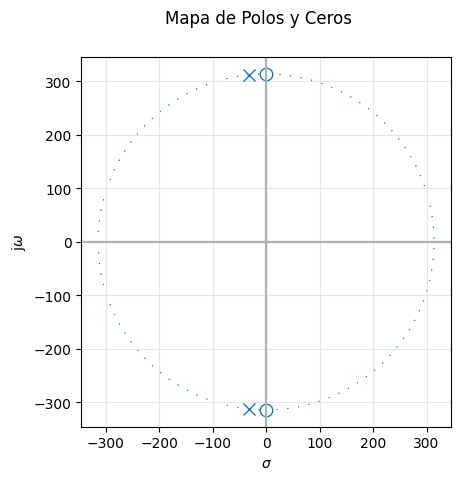

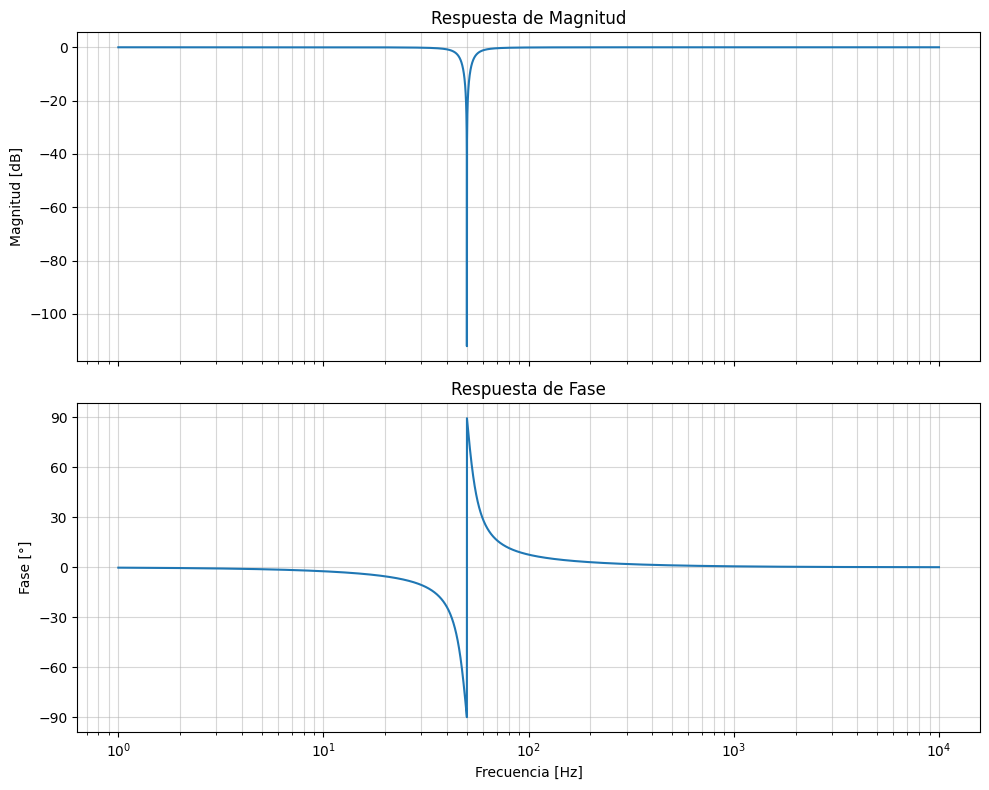

In [2]:
num = [1, 0, (100*np.pi)*(100*np.pi)]
den = [1, 20*np.pi, (100*np.pi)*(100*np.pi)]
T = TransferFunction(num, den)


pzmap(T)
# bodePlot(T)

f = np.logspace(0, 4, 10000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


# Gráfico de Magnitud
ax_mag.semilogx(f, mag)
ax_mag.set_title('Respuesta de Magnitud')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-90, 91, 30)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(f, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.set_xlabel('Frecuencia [Hz]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

### Diseño circuital

Tomamos la topología *Ackerberg-Mosberg*, concatenada con un *sumador*.

<center><img src="./src/img2_LAB1.png"  width="800"></center>

Calculamos los valores de los componentes normalizando para capacitores de $100nF$.

<center><img src="./src/img3_LAB1.png"  width="800"></center>

Los valores de los componentes quedaron:
- $C = 100nF$
- $R_1 = 159,155K\Omega$
- $R_2 = 159,155K\Omega$
- $R_3 = 31,831K\Omega$
- $R_0 = 10K\Omega$ (el valor es anecdótico mientras todos sean iguales)

### Simulación circuital

Simulamos circulamente en *LTspice* el con el amplificador operacional *TL082* (aquel que usamos en la práctica).

<center><img src="./src/img4_LAB1.jpeg"  width="800"></center>

<center><img src="./src/img5_LAB1.jpeg"  width="800"></center>

Se obtienen resultados similares entre simulaciones.

### Diseño de PCB

Para la implementación del fíltro, dada las condiciones de trabajo que te impone este área de la electrónica, no hubieramos podido armar el circuito en una protoboard. Optamos por la elaboración de un PCB.


<center><img src="./src/img6_LAB1.jpeg"  width="800"></center>
<center><img src="./src/img7_LAB1.jpeg"  width="800"></center>

Un par de consideraciones del diseño

- En linea con la sensibilidad propia de estos circuitos optamos por colocar conectores BNC para la reducción de ruido.
- Tambien incluimos un testpoint de la salida *pasa-banda* que va al sumador.
- Añadimos un par de presets a las resistencias $R_3$ para tener un margen de maniobra en caso de necesitar hacer un ajuste (cosa que terminó sucediendo). 

### Resultados de las mediciones
En base a los resultados medidos con osciloscopio recuntruyo las curvas de módulo, fase y retardo de la trasferencia.

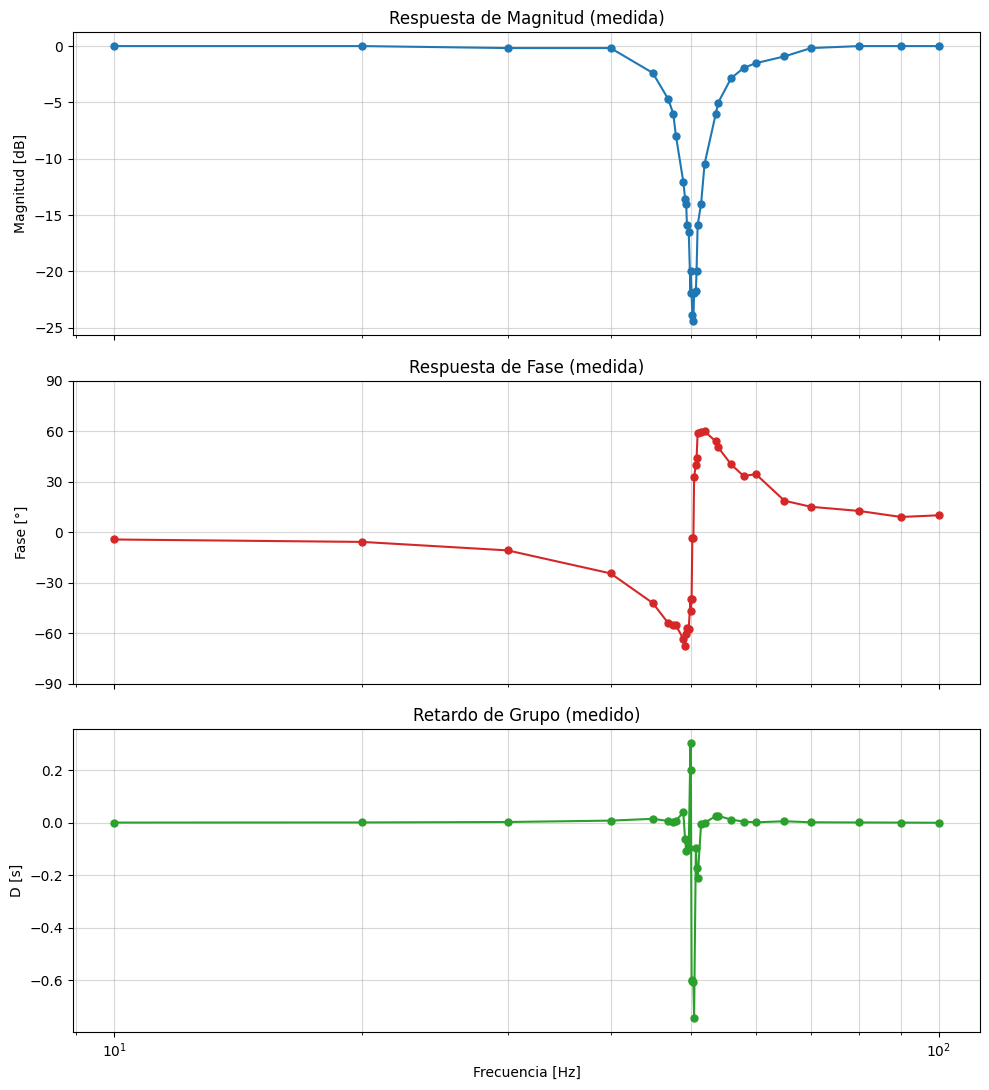

In [14]:
# Datos medidos (discretos): (frecuencia [Hz], Vout [mV], Δt [ms])
datos = [
    (10, 1000, 1.2),
    (20, 1000, 0.8),
    (30, 980, 1),
    (40, 980, 1.7),
    (45, 760, 2.6),
    (47, 580, 3.2),
    (47.65, 500, 3.2),
    (48, 400, 3.2),
    (49, 250, 3.6),
    (49.25, 210, 3.8),
    (49.4, 200, 3.4),
    (49.5, 160, 3.2),
    (49.75, 150, 3.2),
    (50, 80, 2.2),
    (50.05, 100, 2.6),
    (50.15, 80, 2.2),
    (50.25, 64, 0.2),
    (50.4, 60, 0.2),
    (50.5, 80, -1.8),
    (50.75, 82, -2.2),
    (50.85, 100, -2.4),
    (51, 160, -3.2),
    (51.5, 200, -3.2),
    (52, 300, -3.2),
    (53.65, 500, -2.8),
    (54, 560, -2.6),
    (56, 720, -2),
    (58, 800, -1.6),
    (60, 840, -1.6),
    (65, 900, -0.8),
    (70, 980, -0.6),
    (80, 1000, -0.44),
    (90, 1000, -0.28),
    (100, 1000, -0.28),
]

f = np.array([d[0] for d in datos])
vout_mV = np.array([d[1] for d in datos])
dt_ms = np.array([d[2] for d in datos])

# Módulo: usamos Vout como módulo de la transferencia (dB) ya que Vin = 1
mag_medida = 20 * np.log10(vout_mV / 1000)

# Fase: a partir del Δt medido entre entrada y salida
fase_medida = -dt_ms * 0.001* 2 * np.pi * f
fase_deg = np.degrees(fase_medida)

# Retardo de grupo: D = -Δfase/Δomega (fase en rad, omega en rad/s)
omega = 2 * np.pi * f
D = -np.gradient(fase_medida, omega)


# Gráfico de Bode con puntos discretos
fig, (ax_mag, ax_phase, ax_delay) = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

# Magnitud
ax_mag.semilogx(f, mag_medida, "o-", color="tab:blue", markersize=5)
ax_mag.set_title("Respuesta de Magnitud (medida)")
ax_mag.set_ylabel("Magnitud [dB]")
ax_mag.grid(True, which="both", ls="-", alpha=0.5)

# Fase
ax_phase.semilogx(f, fase_deg, "o-", color="tab:red", markersize=5)
ticks = np.arange(-90, 91, 30)
ax_phase.set_yticks(ticks)
ax_phase.set_title("Respuesta de Fase (medida)")
ax_phase.set_ylabel("Fase [°]")
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

# Retardo de grupo
ax_delay.semilogx(f, D, "o-", color="tab:green", markersize=5)
ax_delay.set_title("Retardo de Grupo (medido)")
ax_delay.set_ylabel("D [s]")
ax_delay.set_xlabel("Frecuencia [Hz]")
ax_delay.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

Por último tomamos hicimos una medición con un analizador de espectros. Los resultados son los siguientes.

#### <center> Módulo de la transferencia </center>
<center><img src="./src/img8_LAB1.jpeg"  width="800"></center>

#### <center> Fase de la transferencia </center>
<center><img src="./src/img9_LAB1.jpeg"  width="800"></center>

Los gráficos producto de los resultados de ambos métodos de medición son coherentes con las simulaciones previas y el modelo matemático.

### Aproximación matemática de la respuesta medida

A partir de los puntos medidos se realizó un ajuste no lineal (algoritmo de Levenberg-Marquardt) para obtener la función de transferencia teórica de un filtro notch de 2do orden que mejor se aproxima a los datos experimentales. El ajuste permitió estimar los parámetros característicos del filtro: frecuencia central $f_0 = 49,90Hz$ y  $Q = 6,23$, obteniendo así una expresión matemática continua que describe el comportamiento medido en magnitud y fase, con un ajuste de $R_2 \approx 0,75$.

f0 ajustado = 49.897 Hz  (± 0.035)
Q  ajustado = 6.231      (± 0.790)
R^2 (magnitud) = 0.7514


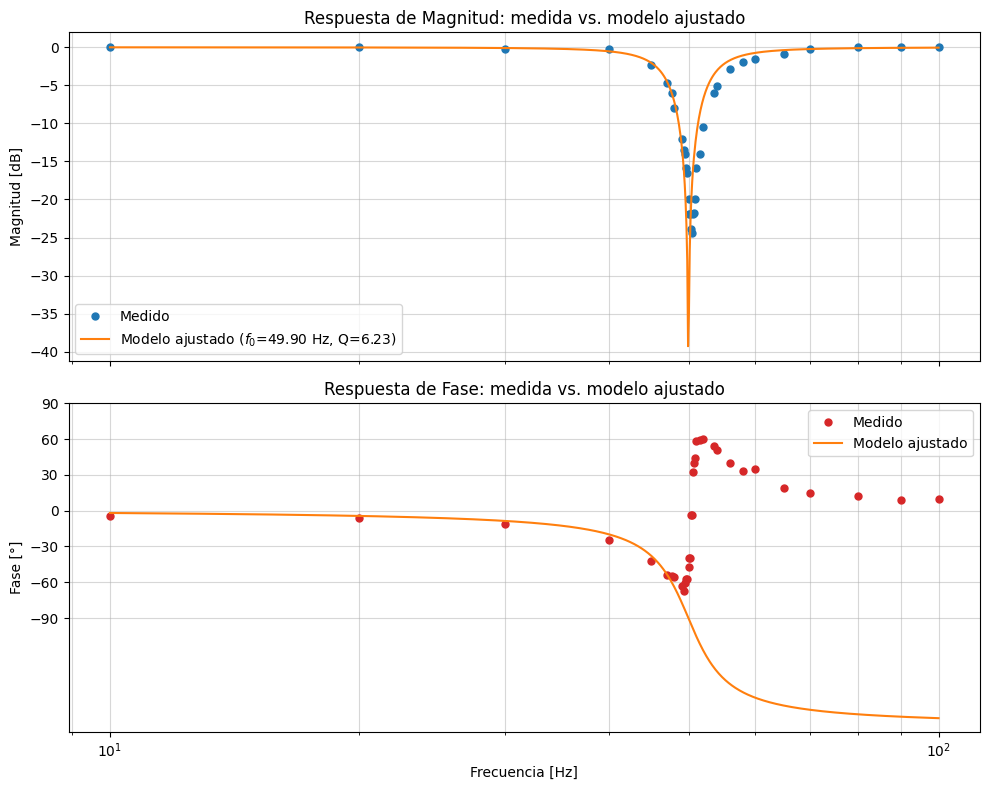

In [16]:
# Modelo teórico:
#           s^2 + w0^2
# H(s) = -----------------------
#         s^2 + (w0/Q) s + w0^2
# Parámetros a ajustar: f0 y Q

def notch_mag_dB(f, f0, Q):
    w, w0 = 2 * np.pi * f, 2 * np.pi * f0
    num = (w0**2 - w**2)**2
    den = num + (w0 * w / Q)**2
    H2 = num / den
    H2 = np.maximum(H2, 1e-12)  # evita log10(0) justo en f = f0
    return 10 * np.log10(H2)

def notch_fase_deg(f, f0, Q):
    w, w0 = 2 * np.pi * f, 2 * np.pi * f0
    fase_rad_modelo = -np.arctan2(w0 * w / Q, w0**2 - w**2)
    return np.degrees(fase_rad_modelo)


# Ajuste no lineal (Levenberg-Marquardt) sobre la magnitud medida
p0 = [50, 5]  # semilla inicial: f0 ~ 50 Hz, Q ~ 5
(f0_fit, Q_fit), cov = curve_fit(notch_mag_dB, f, mag_medida, p0=p0)
errores = np.sqrt(np.diag(cov))

print(f"f0 ajustado = {f0_fit:.3f} Hz  (± {errores[0]:.3f})")
print(f"Q  ajustado = {Q_fit:.3f}      (± {errores[1]:.3f})")


# Bondad del ajuste (R^2) sobre la magnitud
residuos = mag_medida - notch_mag_dB(f, f0_fit, Q_fit)
ss_res = np.sum(residuos**2)
ss_tot = np.sum((mag_medida - np.mean(mag_medida))**2)
r2 = 1 - ss_res / ss_tot
print(f"R^2 (magnitud) = {r2:.4f}")


# Curvas del modelo ajustado (barrido fino en frecuencia)
f_modelo = np.logspace(np.log10(10), np.log10(100), 1000)
mag_modelo = notch_mag_dB(f_modelo, f0_fit, Q_fit)
fase_modelo = notch_fase_deg(f_modelo, f0_fit, Q_fit)


# Gráfico: medido (puntos) vs. modelo ajustado (curva)
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax_mag.semilogx(f, mag_medida, "o", color="tab:blue", markersize=5, label="Medido")
ax_mag.semilogx(f_modelo, mag_modelo, "-", color="tab:orange", lw=1.5, label=f"Modelo ajustado ($f_0$={f0_fit:.2f} Hz, Q={Q_fit:.2f})")
ax_mag.set_title("Respuesta de Magnitud: medida vs. modelo ajustado")
ax_mag.set_ylabel("Magnitud [dB]")
ax_mag.grid(True, which="both", ls="-", alpha=0.5)
ax_mag.legend()

ax_phase.semilogx(f, fase_deg, "o", color="tab:red", markersize=5, label="Medido")
ax_phase.semilogx(f_modelo, fase_modelo, "-", color="tab:orange", lw=1.5, label="Modelo ajustado")
ticks = np.arange(-90, 91, 30)
ax_phase.set_yticks(ticks)
ax_phase.set_title("Respuesta de Fase: medida vs. modelo ajustado")
ax_phase.set_ylabel("Fase [°]")
ax_phase.set_xlabel("Frecuencia [Hz]")
ax_phase.grid(True, which="both", ls="-", alpha=0.5)
ax_phase.legend()

plt.tight_layout()
plt.show()

De esta forma se pueden mostrar los resultados de una forma más presentable.

### Conclusión

Los resultados obtenidos en el trabajo práctico fueron satisfactorios y consistentes con el comportamiento esperado de un filtro notch activo de 2do orden: se verificó la atenuación pronunciada en la frecuencia central $(\approx50Hz)$, con un mínimo de módulo cercano a -24 dB, acompañado del salto característico de fase al atravesar dicha frecuencia, y el consecuente pico en el retardo de grupo en esa misma región. Esto confirma que el circuito cumple su función de rechazo selectivo de banda angosta.

Se observaron, sin embargo, pequeñas diferencias entre los valores obtenidos según el método e instrumento de medición utilizado. Estas discrepancias pueden atribuirse principalmente a las distintas impedancias de entrada de los instrumentos empleados (osciloscopio, analizador de espectro, etc.), que al conectarse al circuito introducen un grado de carga diferente sobre los nodos de medición, afectando levemente la tensión de salida real y, por ende, los valores de módulo y fase.